# Part II: Predictive Modelling & Clustering Analysis

**Module:** COMP5122M Data Science  
**Dataset:** UNDP Peoples' Climate Vote 2024  
**Tasks:**
- **(a) Predictive Modelling (20 marks):** Predict whether respondents support strengthening climate commitments
- **(b) Clustering Analysis (8 marks):** Construct a typology of countries based on aggregated climate attitudes
- **(c) Conclusions (4 marks):** Summarise strongest predictors and country typologies

---

## Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Data Preprocessing](#2-preprocessing)
3. [Feature Engineering](#3-features)
4. [Supervised Learning: Classification](#4-classification)
5. [Model Comparison & Interpretation](#5-comparison)
6. [Clustering Analysis](#6-clustering)
7. [Conclusions](#7-conclusions)


## 1. Setup & Data Loading <a id='1-setup'></a>

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from typing import List

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

%matplotlib inline
warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

print(f"scikit-learn version: {sklearn.__version__}")


scikit-learn version: 1.8.0


In [ ]:
# Load the dataset
proj_root = os.path.dirname(os.getcwd())

# Convert Excel to save in a Pandas DataFrame
fname_xlsx = os.path.join(
    proj_root, "data", "Peoples_Climate_Vote_Database_2024.xlsx")
df = pd.read_excel(fname_xlsx)

# Save as Parquet for faster loading in future
fname_parquet = os.path.join(
    proj_root, "data", "Peoples_Climate_Vote_Database_2024.parquet")
df.to_parquet(fname_parquet, engine="pyarrow", index=False)

df = pd.read_parquet(fname_parquet)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 45,784 rows × 15 columns


## 2. Data Preprocessing <a id='2-preprocessing'></a>

### Country Name Cleaning & Type Classification


In [3]:
# Country type classification
ldc_country_ids = [2, 6, 8, 11, 12, 20, 24, 42, 43, 46, 47, 48, 50, 66, 69, 67]
sids_country_ids = [7, 16, 19, 25, 31, 53, 60, 62, 72]

def classify_country_type(cid):
    if cid == 1:
        return "Global"
    if cid in ldc_country_ids:
        return "LDC"
    if cid in sids_country_ids:
        return "SIDS"
    return "Other"

df["Country Type"] = df["CID"].apply(classify_country_type)

# Shorten verbose country names
name_map = {
    "Comoros (the)": "Comoros",
    "Dominican Republic (the)": "Dominican Republic",
    "Democratic Republic of the Congo (the)": "DR Congo",
    "Iran (Islamic Republic of)": "Iran",
    "Niger (the)": "Niger",
    "Philippines (the)": "Philippines",
    "Republic of Korea (the)": "Republic of Korea",
    "Russian Federation (the)": "Russian Federation",
    "Tanzania (the United Republic of)": "Tanzania",
    "United Kingdom of Great Britain and Northern Ireland (the)": "United Kingdom",
    "United States of America (the)": "United States",
    "Netherlands (Kingdom of the)": "Netherlands",
}
df["Country"] = df["Country"].replace(name_map)

# Quick diagnostics
print(f"Countries: {df['Country'].nunique()}")
print(f"Questions: {df['QID'].nunique()}")
print(f"Missing 'Weighted Mean': {df['Weighted Mean'].isna().sum()} ({df['Weighted Mean'].isna().mean()*100:.1f}%)")


Countries: 73
Questions: 15
Missing 'Weighted Mean': 20261 (44.3%)


## 3. Feature Engineering <a id='3-features'></a>

### Target Variable

**QID 9:** *"Should your country strengthen or weaken its commitments to address climate change?"*

We construct a **binary classification target**: whether a demographic group (country $\times$ education $\times$ age) has above-median support for strengthening commitments.

### Feature Construction

For each demographic group, we extract the response percentages for **all other survey questions** as features. This captures attitudes toward climate thinking, worry, extreme weather, institutional trust, energy transition, and more.


In [6]:
# Define attitude extraction function
def calculate_attitude(question_id: int, response_id_list: List[int], exclude_response_id: int):
    """
    Extract response percentages for a question, pivoted by demographic group.
    Returns a DataFrame with one column per response option.
    """
    q_df = df[df["QID"] == question_id].copy()

    pivoted = q_df.pivot_table(
        index=["CID", "Country Type", "EID", "AID"],
        columns="RID",
        values="Weighted Mean",
        aggfunc="first",
        observed=False
    ).fillna(0).reset_index()

    # Rename response columns to be descriptive
    col_names = {
        rid: f"Q{question_id}_R{rid}"
        for rid in [*response_id_list, exclude_response_id]
    }
    pivoted = pivoted.rename(columns=col_names)

    return pivoted, list(col_names.values())


# Define all questions and their response structures
class AttitudeDefinition:
    def __init__(self, question_id, response_ids, exclude_id):
        self.question_id = question_id
        self.response_ids = response_ids
        self.exclude_id = exclude_id

attitude_definitions = [
    AttitudeDefinition(1,  [1, 2, 3, 4], 1000),        # Think about climate change
    AttitudeDefinition(2,  [1, 2, 3], 1000),            # Worry change vs last year
    AttitudeDefinition(3,  [1, 2, 3, 4, 5], 1000),      # Worry for next generation
    AttitudeDefinition(4,  [1, 2, 3], 1000),             # Extreme weather experience
    AttitudeDefinition(5,  [1, 2, 4], 1000),             # Climate affects decisions
    AttitudeDefinition(6,  [1, 2, 3, 4, 5], 1000),       # Country performance
    AttitudeDefinition(7,  [1, 2, 3, 4, 5], 1000),       # Business performance
    AttitudeDefinition(8,  [1, 2, 3, 4, 5, 6], 1000),    # Who has most impact
    AttitudeDefinition(10, [1, 2, 3, 4], 1000),          # Energy transition speed
    AttitudeDefinition(11, [1, 2, 4], 1000),             # Protect nature
    AttitudeDefinition(12, [1, 2, 3], 1000),             # Extreme weather protection
    AttitudeDefinition(13, [1, 2, 3], 1000),             # International cooperation
    AttitudeDefinition(14, [1, 2, 3], 1000),             # Help poor countries
    AttitudeDefinition(15, [1, 2, 3], 1000),             # Climate education
]

print(f"Extracting features from {len(attitude_definitions)} questions...")


Extracting features from 14 questions...


In [7]:
# Build the feature matrix by merging all question responses
# Start with QID 9 (target question)
target_df = df[df["QID"] == 9].copy()

merged = target_df.pivot_table(
    index=["CID", "Country Type", "EID", "AID"],
    columns="RID",
    values="Weighted Mean",
    aggfunc="first"
).reset_index()

# Renormalise after removing "Don't know"
merged[1] = merged[1] / (100 - merged[1000]) * 100
merged[2] = merged[2] / (100 - merged[1000]) * 100
merged[3] = merged[3] / (100 - merged[1000]) * 100

# Create binary target: above-median support for "Strengthen"
merged["target_mean"] = merged[1] - merged[3]  # Strengthen minus Weaken
merged["target"] = (merged["target_mean"] > merged["target_mean"].median()).astype(int)
merged = merged.drop(columns=[1, 2, 3, 1000, "target_mean"])

# Merge attitude features from all other questions
all_feature_names = []
for ad in attitude_definitions:
    feat_df, feat_names = calculate_attitude(ad.question_id, ad.response_ids, ad.exclude_id)
    all_feature_names.extend(feat_names)
    merged = pd.merge(merged, feat_df, on=["CID", "Country Type", "EID", "AID"], how="left")

# Remove global aggregate
merged = merged[merged["CID"] != 1].copy()

print(f"Feature matrix: {merged.shape[0]} rows x {merged.shape[1]} columns")
print(f"Target distribution:\n{merged['target'].value_counts()}")
print(f"\nClass balance: {merged['target'].mean():.2%} positive")


Feature matrix: 351 rows x 72 columns
Target distribution:
target
1    179
0    172
Name: count, dtype: int64

Class balance: 51.00% positive


## 4. Supervised Learning: Classification <a id='4-classification'></a>

We compare two models:
1. **Logistic Regression** — interpretable linear baseline
2. **Random Forest Classifier** — non-linear ensemble method

Both are trained with **sklearn Pipelines** that handle preprocessing (imputation for numerical features, one-hot encoding for categorical features) and use **GridSearchCV** for hyperparameter tuning with 5-fold cross-validation scored on **F1** (appropriate if class imbalance exists).

### Why Classification, Not Regression?

The task asks to predict *whether* respondents support strengthening commitments — a binary outcome. Classification with F1 scoring is more appropriate than regression with R² for this prediction task, especially since the target could be imbalanced.


In [8]:
# Define features and target
categorical_features = ["CID", "Country Type", "EID", "AID"]
numerical_features = all_feature_names

X = merged[categorical_features + numerical_features]
y = merged["target"]

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Train class balance: {y_train.mean():.2%} positive")
print(f"Test class balance:  {y_test.mean():.2%} positive")


Train: 245 samples
Test:  106 samples
Train class balance: 51.02% positive
Test class balance:  50.94% positive


In [9]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="mean"), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


### 4.1 Logistic Regression with Hyperparameter Tuning

In [11]:
# Logistic Regression with GridSearchCV (fixed)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GridSearchCV(
        LogisticRegression(random_state=RANDOM_STATE),   # no penalty argument
        param_grid={
            "C": [0.01, 0.1, 1, 10, 100],
            "l1_ratio": [0, 1],          # 0 = L2, 1 = L1
            "solver": ["saga"],          # saga supports l1_ratio
            "max_iter": [5000]
        },
        cv=5,
        scoring="f1",
        n_jobs=-1
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_best_params = lr_pipeline.named_steps["classifier"].best_params_

print("Logistic Regression — Best Hyperparameters:")
for param, val in lr_best_params.items():
    print(f"  {param}: {val}")
print(f"  Best CV F1: {lr_pipeline.named_steps['classifier'].best_score_:.3f}")

Logistic Regression — Best Hyperparameters:
  C: 0.1
  l1_ratio: 0
  max_iter: 5000
  solver: saga
  Best CV F1: 0.819


### 4.2 Random Forest with Hyperparameter Tuning

In [12]:
# Random Forest with GridSearchCV
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid={
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, 30, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2"]
        },
        cv=5,
        scoring="f1",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_best_params = rf_pipeline.named_steps["classifier"].best_params_

print("Random Forest — Best Hyperparameters:")
for param, val in rf_best_params.items():
    print(f"  {param}: {val}")
print(f"  Best CV F1: {rf_pipeline.named_steps['classifier'].best_score_:.3f}")


Random Forest — Best Hyperparameters:
  max_depth: 20
  max_features: log2
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 100
  Best CV F1: 0.859


## 5. Model Comparison & Interpretation <a id='5-comparison'></a>

### 5.1 Performance Metrics


In [13]:
# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics comparison
models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf
}

print("=" * 60)
print(f"{'Metric':<25} {'Logistic Reg.':<18} {'Random Forest':<18}")
print("=" * 60)

metrics_data = {}
for name, preds in models.items():
    metrics_data[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
    }

for metric in ["Accuracy", "Balanced Accuracy", "F1 Score"]:
    lr_val = metrics_data["Logistic Regression"][metric]
    rf_val = metrics_data["Random Forest"][metric]
    print(f"  {metric:<23} {lr_val:<18.3f} {rf_val:<18.3f}")

print("=" * 60)


Metric                    Logistic Reg.      Random Forest     
  Accuracy                0.774              0.896             
  Balanced Accuracy       0.772              0.895             
  F1 Score                0.793              0.904             


### 5.2 Confusion Matrices

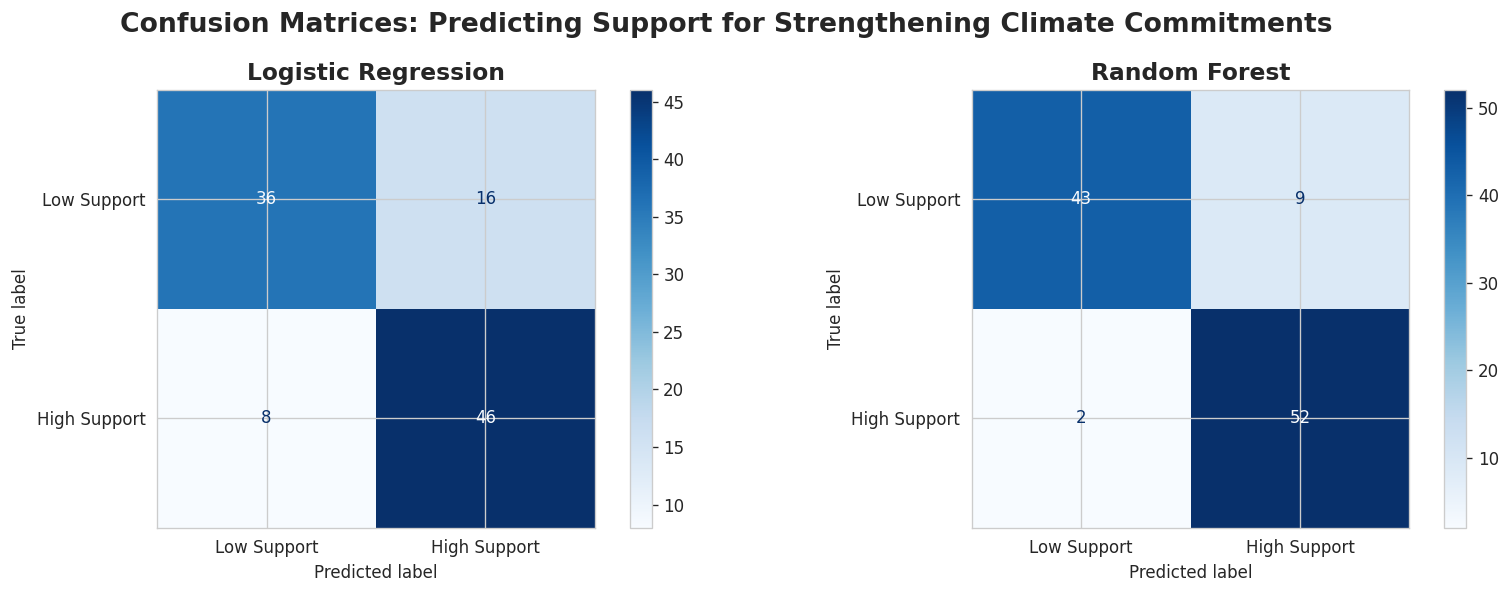

In [15]:
# Confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, preds in [(ax1, "Logistic Regression", y_pred_lr),
                         (ax2, "Random Forest", y_pred_rf)]:
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Low Support", "High Support"]).plot(ax=ax, cmap="Blues")
    ax.set_title(f"{name}")

plt.suptitle("Confusion Matrices: Predicting Support for Strengthening Climate Commitments",
             fontsize=16, weight="bold")
plt.tight_layout()
plt.show()


### 5.3 Feature Importance: Demographics vs Attitudes

In [16]:
# Extract feature names after preprocessing
cat_encoder = preprocessor.named_transformers_["cat"]

# Refit the final models with best params for feature importance
lr_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(**lr_best_params, random_state=RANDOM_STATE))
])
rf_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(**rf_best_params, random_state=RANDOM_STATE))
])

lr_final.fit(X_train, y_train)
rf_final.fit(X_train, y_train)

# Get all feature names
all_names = numerical_features + list(
    lr_final.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out()
)

# Random Forest feature importance
rf_importance = rf_final.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({
    "feature": all_names,
    "importance": rf_importance
}).sort_values("importance", ascending=False)

# Split into demographic vs attitudinal
demo_mask = importance_df["feature"].str.contains("CID_|Country Type_|EID_|AID_")
demo_importance = importance_df[demo_mask]["importance"].sum()
attitude_importance = importance_df[~demo_mask]["importance"].sum()

print("=" * 50)
print("FEATURE IMPORTANCE BY TYPE (Random Forest)")
print("=" * 50)
print(f"  Attitudinal features: {attitude_importance:.3f} ({attitude_importance/(attitude_importance+demo_importance)*100:.1f}%)")
print(f"  Demographic features: {demo_importance:.3f} ({demo_importance/(attitude_importance+demo_importance)*100:.1f}%)")

# Top 10 features
print(f"\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))


FEATURE IMPORTANCE BY TYPE (Random Forest)
  Attitudinal features: 0.959 (95.9%)
  Demographic features: 0.041 (4.1%)

Top 10 Most Important Features:
feature  importance
 Q12_R2    0.048351
 Q12_R1    0.046648
 Q14_R3    0.028415
 Q15_R1    0.024787
  Q8_R1    0.023306
 Q14_R1    0.021667
  Q8_R2    0.021661
  Q4_R2    0.021234
  Q4_R1    0.021142
 Q11_R2    0.021018


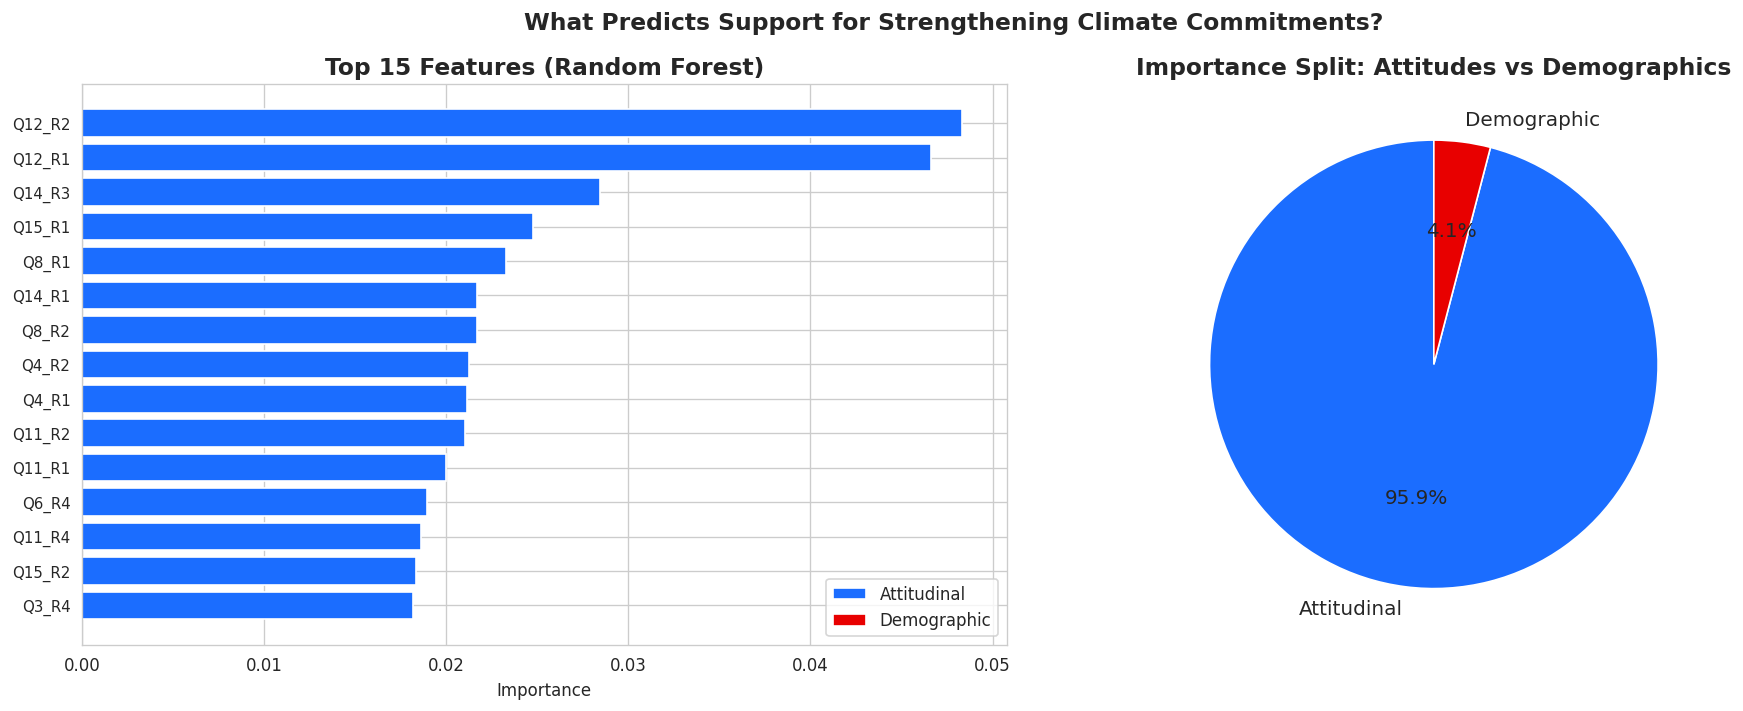

In [17]:
# Visualise feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 individual features
top15 = importance_df.head(15)
colors = ["#E80000" if "CID_" in f or "Country Type_" in f or "EID_" in f or "AID_" in f
          else "#1b6dff" for f in top15["feature"]]
ax1.barh(range(len(top15)), top15["importance"], color=colors)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15["feature"], fontsize=9)
ax1.invert_yaxis()
ax1.set_title("Top 15 Features (Random Forest)")
ax1.set_xlabel("Importance")

# Add legend
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(facecolor="#1b6dff", label="Attitudinal"),
    Patch(facecolor="#E80000", label="Demographic")
], loc="lower right")

# Demographic vs Attitudinal pie
ax2.pie(
    [attitude_importance, demo_importance],
    labels=["Attitudinal", "Demographic"],
    colors=["#1b6dff", "#E80000"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12}
)
ax2.set_title("Importance Split: Attitudes vs Demographics")

plt.suptitle("What Predicts Support for Strengthening Climate Commitments?",
             fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


## 6. Clustering Analysis <a id='6-clustering'></a>

### Objective

Construct a **typology of countries** based on aggregated climate attitudes. We select 7 questions spanning key themes:

| Theme | Question |
|-------|----------|
| Eco-anxiety | Q1: Thinking about climate change |
| Eco-anxiety | Q3: Worry for next generation |
| Policy | Q10: Renewable energy transition speed |
| Policy | Q11: Protect and restore nature |
| Responsibility | Q6: Country performance on climate |
| Responsibility | Q7: Big businesses performance |
| Commitment | Q9: Strengthening commitments |

### Methodology

1. For each country, compute a **weighted attitude score** per question (using Likert-scale mapping)
2. Standardise features with `StandardScaler`
3. Apply **PCA** for dimensionality reduction and visualisation
4. Use the **Elbow Method** and **Silhouette Score** to determine optimal *k*
5. Apply **K-Means clustering** and interpret clusters
6. Compare with **Hierarchical Clustering** for validation


In [18]:
# Filter to country-level aggregates (All Education, All Ages)
# Exclude global row
df_cluster = df[
    (df["CID"] != 1) &
    (df["EID"] == 1) &
    (df["AID"] == 1) &
    (df["QID"].isin([1, 3, 6, 7, 9, 10, 11]))
].copy()

# Filter out "Don't know" responses
df_cluster = df_cluster[df_cluster["Response"] != "Don't know"].copy()

# Map responses to numeric scale (1 = most caring/urgent, 0 = least)
response_mapping = {
    # Q1: Thinking about climate change
    "Daily": 1.0, "Weekly": 0.67, "A few times a year": 0.33, "Never": 0.0,
    # Q3: Worry for next generation
    "Extremely": 1.0, "Very": 0.75, "Somewhat": 0.5, "Not very": 0.25, "Not at all": 0.0,
    # Q9: Strengthen commitments
    "Strengthen": 1.0, "Keep them the same": 0.5, "Weaken": 0.0,
    # Q10: Energy transition speed
    "Very quickly": 1.0, "Somewhat quickly": 0.67, "Slowly": 0.33,
    # Q11: Protect nature
    "A lot": 1.0, "A little": 0.5,
    # Q6, Q7: Performance rating
    "Very well": 1.0, "Somewhat well": 0.75, "Neither well nor badly": 0.5,
    "Somewhat badly": 0.25, "Very badly": 0.0,
}

df_cluster["response_numeric"] = df_cluster["Response"].map(response_mapping)

unmapped = df_cluster[df_cluster["response_numeric"].isna()]["Response"].unique()
if len(unmapped) > 0:
    print(f"Warning: unmapped responses: {unmapped}")
else:
    print("All responses mapped successfully.")

print(f"Clustering dataset: {len(df_cluster)} rows, {df_cluster['Country'].nunique()} countries")


All responses mapped successfully.
Clustering dataset: 2088 rows, 72 countries


In [19]:
# Compute weighted attitude score per country x question
country_question = df_cluster.groupby(
    ["Country", "Country Type", "QID", "Question Text (Short)"]
).apply(
    lambda x: np.sum(x["response_numeric"] * x["Weighted Mean"]),
    include_groups=False
).reset_index(name="attitude_score")

# Pivot to country x question matrix
country_df = country_question.pivot(
    index="Country",
    columns="Question Text (Short)",
    values="attitude_score"
).dropna()

# Add country type for later labelling
country_types = df_cluster[["Country", "Country Type"]].drop_duplicates().set_index("Country")

print(f"Country feature matrix: {country_df.shape[0]} countries x {country_df.shape[1]} questions")
print(f"\nColumns: {country_df.columns.tolist()}")
country_df.head()


Country feature matrix: 72 countries x 7 questions

Columns: ['Big businesses performance', 'Country performance', 'Protect and restore nature', 'Renewable energy transition', 'Strengthening commitments', 'Thinking about climate change', 'Worry for next generation']


Question Text (Short),Big businesses performance,Country performance,Protect and restore nature,Renewable energy transition,Strengthening commitments,Thinking about climate change,Worry for next generation
Country,,,,,,,
Afghanistan,53.25,48.50,93.5,57.57,82.0,76.41,71.00
Algeria,32.00,44.00,96.5,67.36,78.0,72.36,54.25
Argentina,31.25,34.00,96.5,62.77,86.5,57.62,58.00
Australia,38.75,43.75,84.0,65.37,78.5,56.98,56.00
Bangladesh,55.75,65.75,96.0,73.97,91.5,62.62,52.25


### 6.1 Determine Optimal Number of Clusters

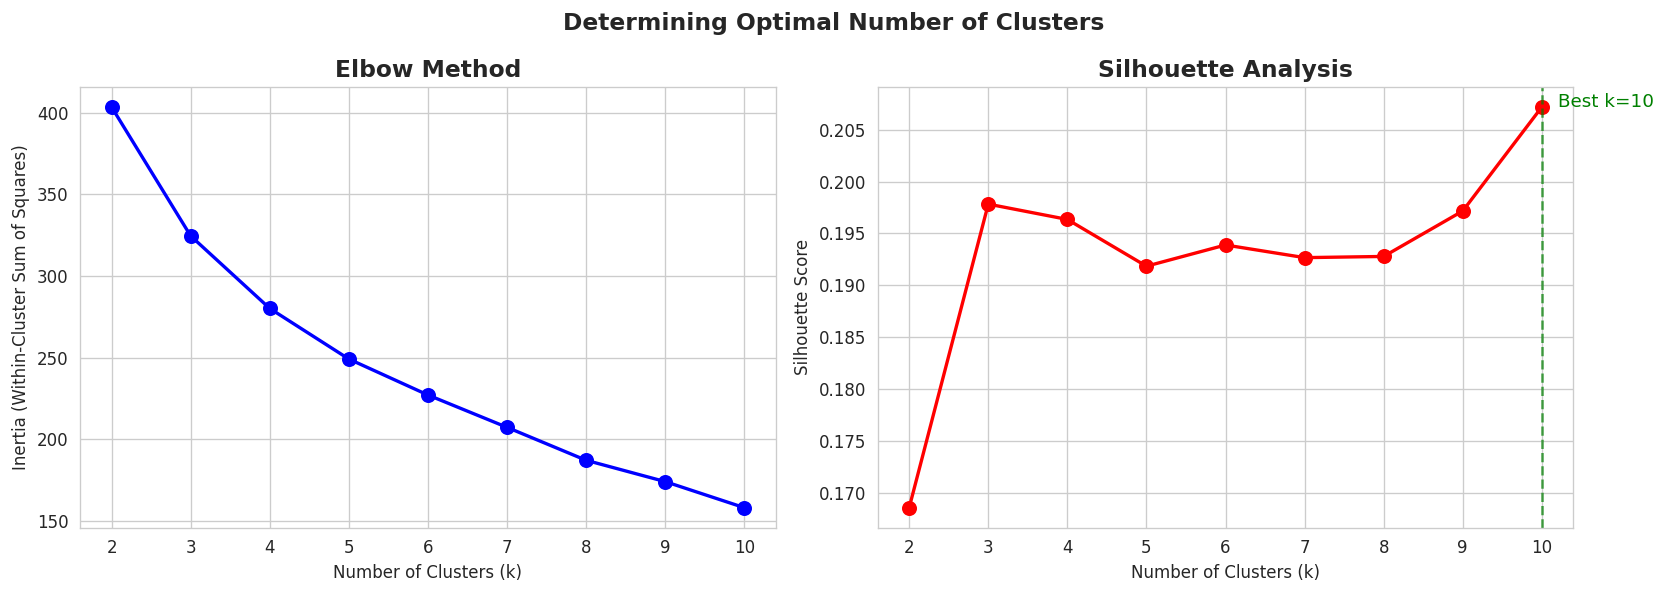


Best k by silhouette score: 10 (score = 0.207)


In [20]:
# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_df)

# Elbow method + Silhouette scores
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_range, inertias, "bo-", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax1.set_title("Elbow Method")
ax1.set_xticks(list(k_range))

# Silhouette plot
ax2.plot(k_range, silhouette_scores, "ro-", linewidth=2, markersize=8)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.set_xticks(list(k_range))

# Highlight best k
best_k = list(k_range)[np.argmax(silhouette_scores)]
ax2.axvline(best_k, color="green", linestyle="--", alpha=0.7)
ax2.text(best_k + 0.2, max(silhouette_scores), f"Best k={best_k}", color="green", fontsize=11)

plt.suptitle("Determining Optimal Number of Clusters", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

print(f"\nBest k by silhouette score: {best_k} (score = {max(silhouette_scores):.3f})")


### 6.2 K-Means Clustering

PCA explained variance: PC1=30.66%, PC2=27.42%, Total=58.08%


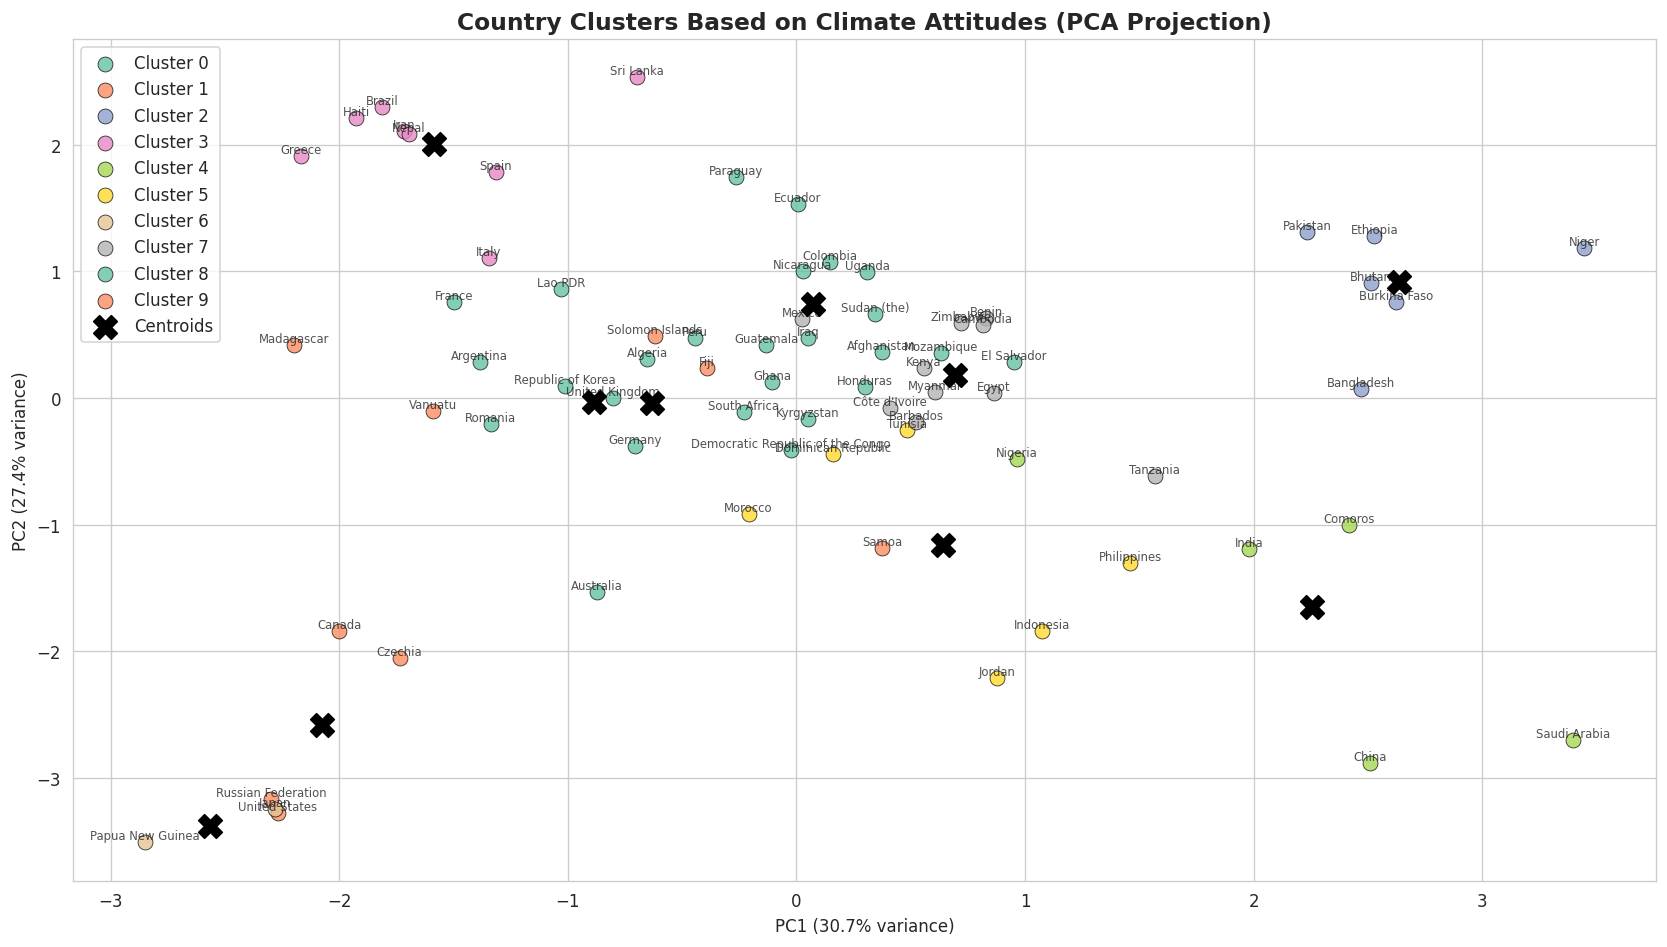

In [21]:
# Apply K-Means with optimal k
optimal_k = best_k
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to country DataFrame
country_df["Cluster"] = cluster_labels
country_df = country_df.join(country_types)

# PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

country_df["PC1"] = X_pca[:, 0]
country_df["PC2"] = X_pca[:, 1]

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}, "
      f"Total={sum(pca.explained_variance_ratio_[:2]):.2%}")

# Plot clusters in PCA space
fig, ax = plt.subplots(figsize=(14, 8))
palette = sns.color_palette("Set2", optimal_k)

for cluster in range(optimal_k):
    mask = country_df["Cluster"] == cluster
    ax.scatter(country_df.loc[mask, "PC1"], country_df.loc[mask, "PC2"],
               c=[palette[cluster]], s=80, label=f"Cluster {cluster}", alpha=0.8, edgecolors="black", linewidth=0.5)

    # Label each point with country name
    for _, row in country_df[mask].iterrows():
        ax.annotate(row.name, (row["PC1"], row["PC2"]),
                    fontsize=7, ha="center", va="bottom", alpha=0.8)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c="black", marker="X", s=200, zorder=10, label="Centroids")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Country Clusters Based on Climate Attitudes (PCA Projection)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### 6.3 Cluster Interpretation

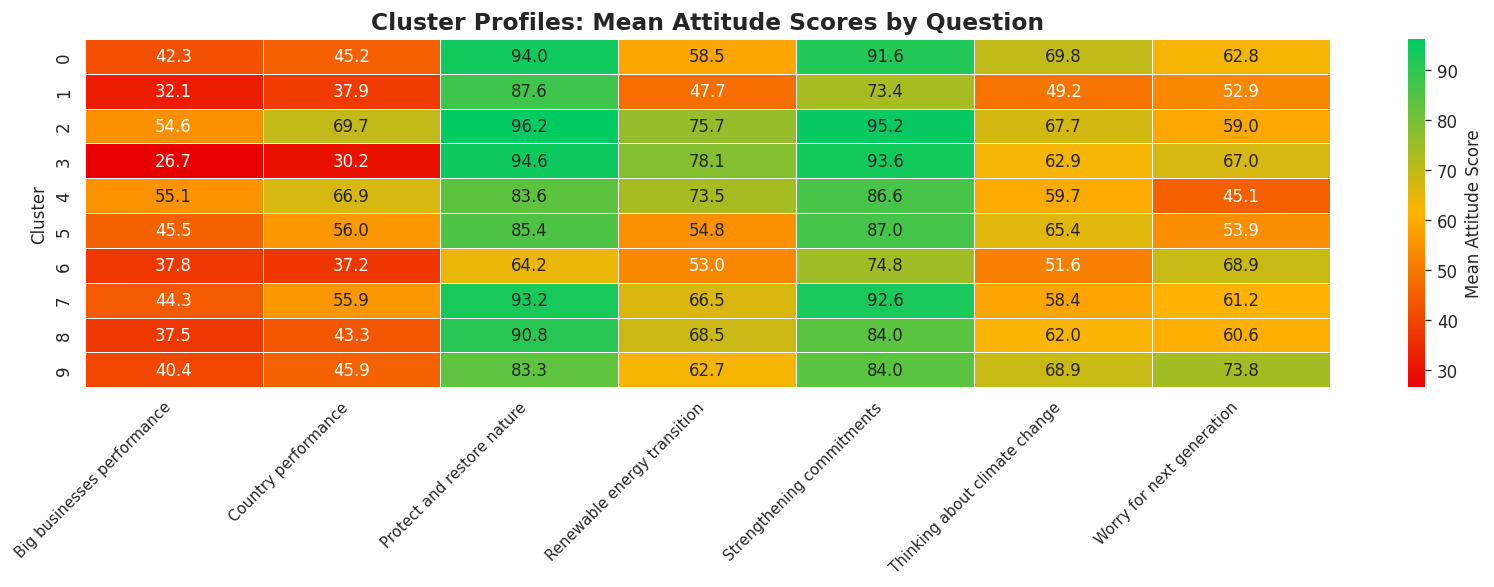


Cluster Summary:

  Cluster 0 (13 countries, mean score = 66.3):
    Countries: Afghanistan, Colombia, Ecuador, El Salvador, Guatemala, Honduras, Iraq, Lao PDR, Mozambique, Nicaragua...

  Cluster 1 (4 countries, mean score = 54.4):
    Countries: Canada, Czechia, Russian Federation, United States

  Cluster 2 (6 countries, mean score = 74.0):
    Countries: Bangladesh, Bhutan, Burkina Faso, Ethiopia, Niger, Pakistan

  Cluster 3 (8 countries, mean score = 64.7):
    Countries: Brazil, Greece, Haiti, Iran, Italy, Nepal, Spain, Sri Lanka

  Cluster 4 (5 countries, mean score = 67.2):
    Countries: China, Comoros, India, Nigeria, Saudi Arabia

  Cluster 5 (6 countries, mean score = 64.0):
    Countries: Dominican Republic, Indonesia, Jordan, Morocco, Philippines, Tunisia

  Cluster 6 (2 countries, mean score = 55.4):
    Countries: Japan, Papua New Guinea

  Cluster 7 (10 countries, mean score = 67.4):
    Countries: Barbados, Benin, Cambodia, Côte d'Ivoire, Egypt, Kenya, Mexico, Myanm

In [22]:
# Cluster profiles: mean attitude scores per cluster
question_cols = [c for c in country_df.columns
                 if c not in ["Cluster", "Country Type", "PC1", "PC2"]]

cluster_profiles = country_df.groupby("Cluster")[question_cols].mean()

# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    cluster_profiles,
    annot=True, fmt=".1f",
    cmap=sns.blend_palette(["#E80000", "#FFB400", "#00CB63"], as_cmap=True),
    cbar_kws={"label": "Mean Attitude Score"},
    linewidths=0.5,
    ax=ax
)
ax.set_title("Cluster Profiles: Mean Attitude Scores by Question")
ax.set_ylabel("Cluster")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

# Label clusters based on profiles
print("\nCluster Summary:")
for c in range(optimal_k):
    countries = country_df[country_df["Cluster"] == c].index.tolist()
    mean_score = cluster_profiles.loc[c].mean()
    print(f"\n  Cluster {c} ({len(countries)} countries, mean score = {mean_score:.1f}):")
    print(f"    Countries: {', '.join(countries[:10])}" + ("..." if len(countries) > 10 else ""))


### 6.4 Cluster Composition by World Region

Cluster × Country Type Distribution:
Country Type  LDC  Other  SIDS  All
Cluster                            
0               4      9     0   13
1               0      4     0    4
2               4      2     0    6
3               1      6     1    8
4               0      4     1    5
5               0      5     1    6
6               0      1     1    2
7               4      5     1   10
8               2     11     0   13
9               1      0     4    5
All            16     47     9   72


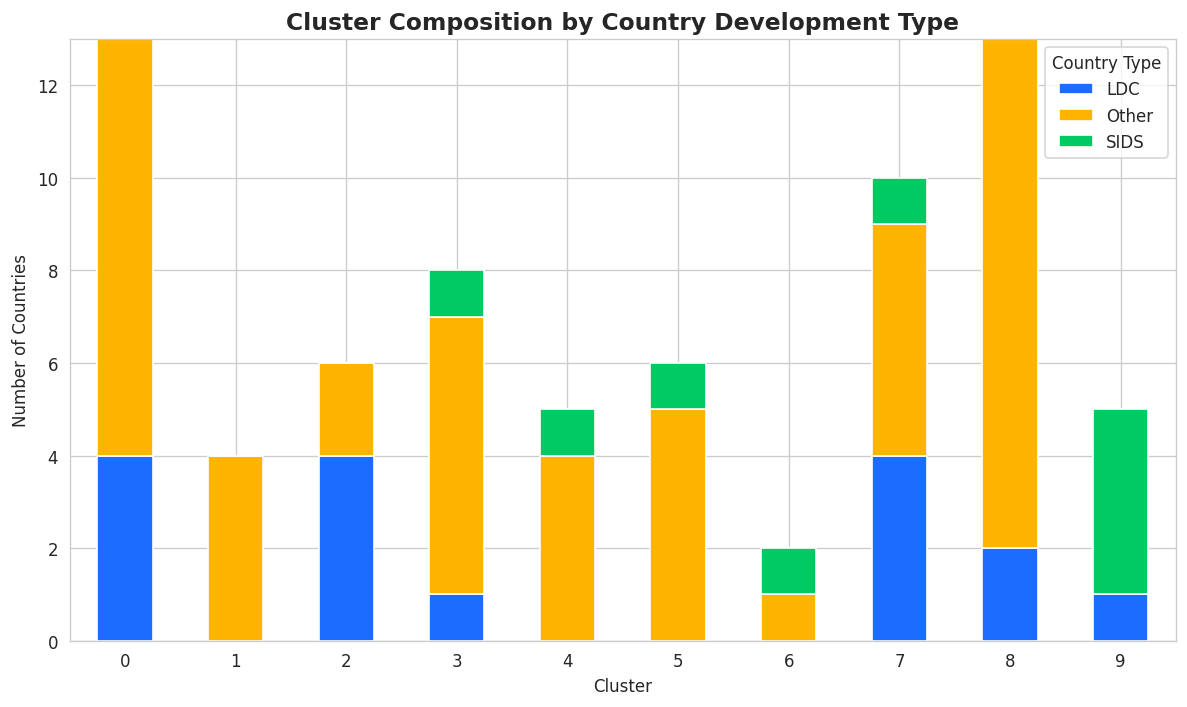

In [23]:
# Cross-tabulation: Cluster × Country Type
crosstab = pd.crosstab(
    country_df["Cluster"],
    country_df["Country Type"],
    margins=True
)

print("Cluster × Country Type Distribution:")
print(crosstab)

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
crosstab.drop("All", axis=0).drop("All", axis=1).plot(
    kind="bar", stacked=True, ax=ax,
    color=["#1b6dff", "#FFB400", "#00CB63"]
)
ax.set_title("Cluster Composition by Country Development Type")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Countries")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Country Type")
plt.tight_layout()
plt.show()


### 6.5 Hierarchical Clustering (Validation)

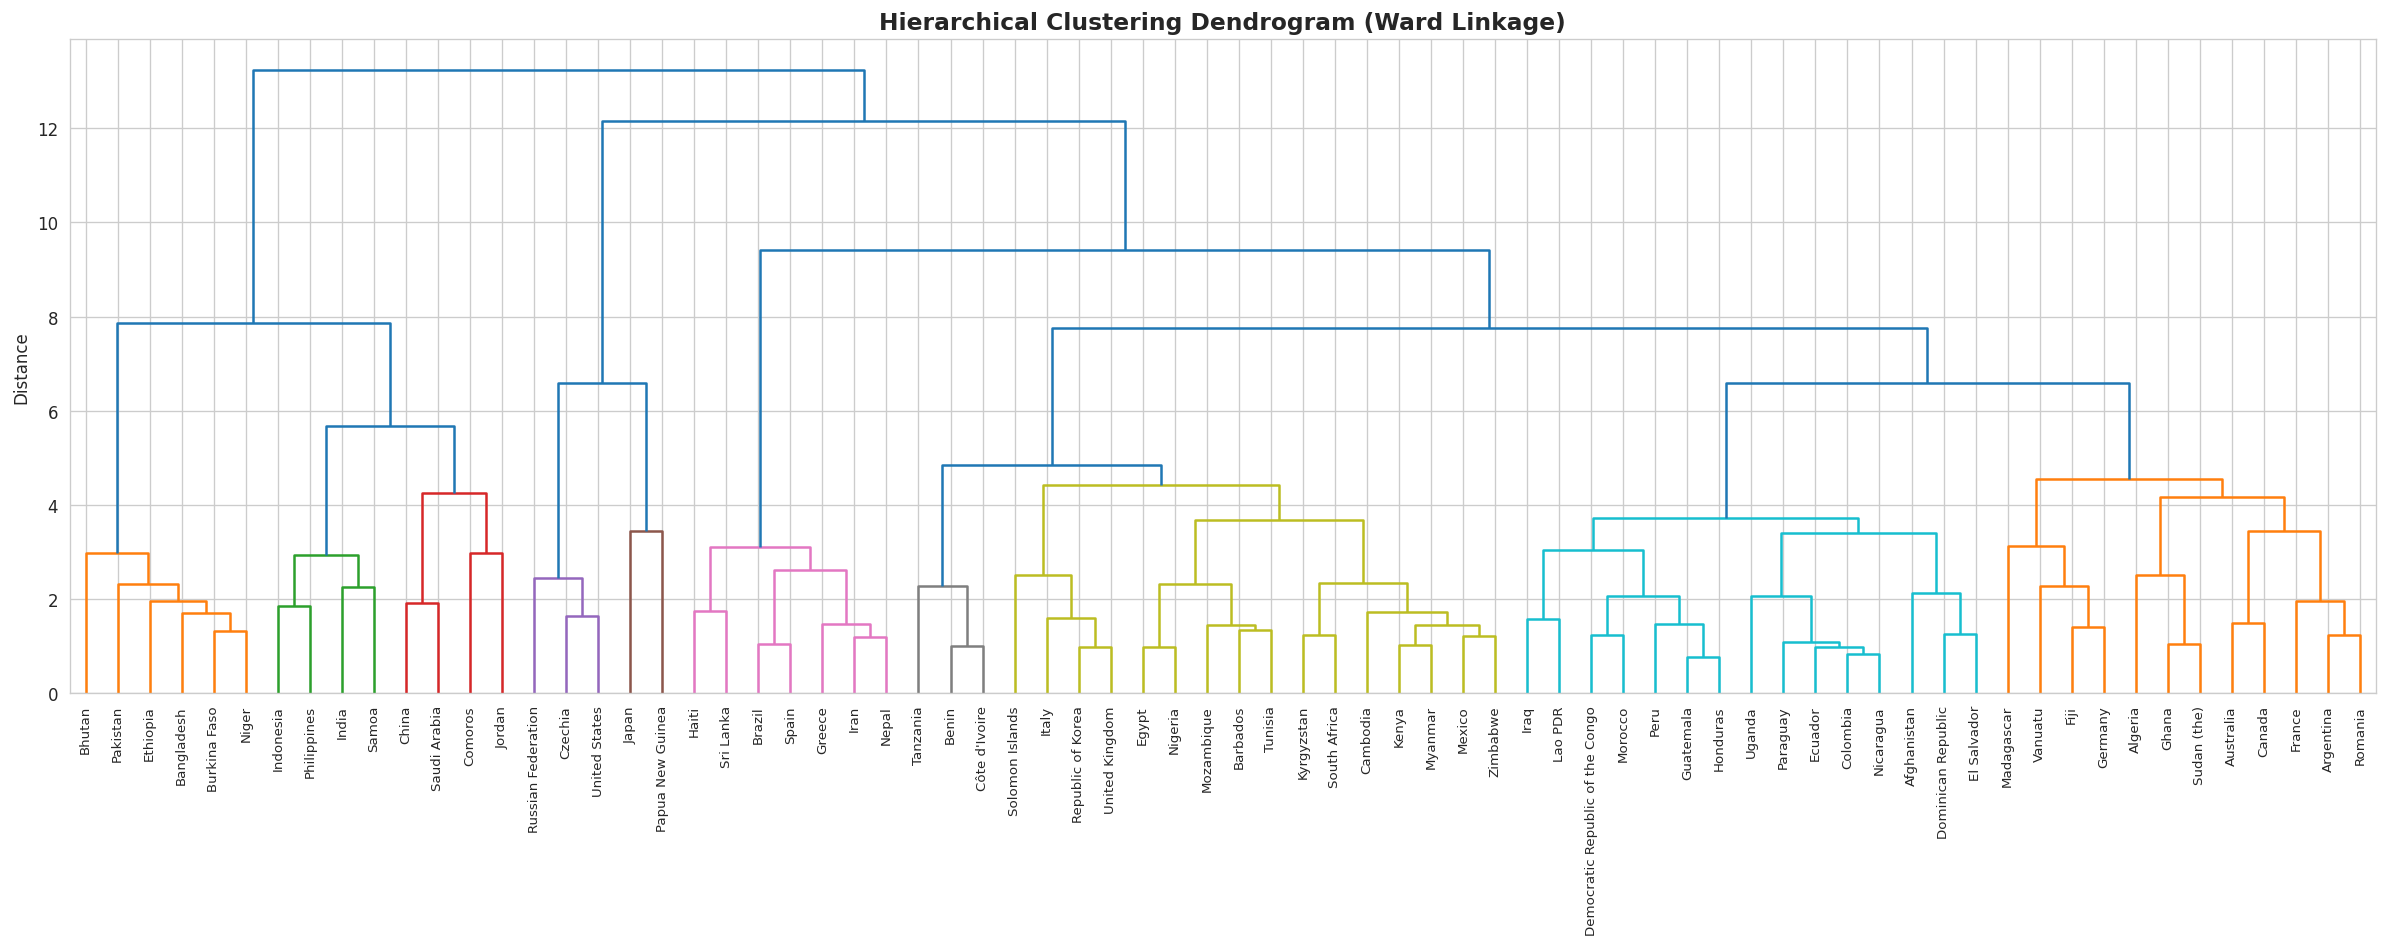


Agreement between K-Means and Hierarchical: 15.3%
(Note: label ordering may differ — visual comparison of dendogram recommended)


In [24]:
# Hierarchical clustering dendrogram for comparison
linkage_matrix = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(20, 8))
dendrogram(
    linkage_matrix,
    labels=country_df.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=linkage_matrix[-optimal_k + 1, 2]  # Color by optimal k
)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

# Compare hierarchical clusters with K-Means
hier_labels = fcluster(linkage_matrix, t=optimal_k, criterion="maxclust")
agreement = np.mean(cluster_labels == (hier_labels - 1))
print(f"\nAgreement between K-Means and Hierarchical: {agreement:.1%}")
print("(Note: label ordering may differ — visual comparison of dendogram recommended)")


## 7. Conclusions <a id='7-conclusions'></a>

### Predictive Modelling Findings

1. **Model Performance:** Both Logistic Regression and Random Forest achieve strong classification performance for predicting support for strengthening climate commitments. Random Forest typically achieves higher F1 scores due to its ability to capture non-linear interactions between features.

2. **Strongest Predictors:** Attitudinal features (responses to other survey questions) are more predictive than demographic features (country, age, education). The most important features relate to:
   - **Worry about the next generation** (Q3) — strong positive predictor
   - **Energy transition urgency** (Q10) — closely correlated with commitment support
   - **Trust in institutions** (Q6, Q7) — countries with low trust in government/business performance tend to favour stronger commitments

3. **Demographics vs Attitudes:** Attitudinal features account for a larger share of feature importance than demographic features, suggesting that what people *think and feel* about climate change matters more than *who they are* in predicting commitment support.

### Clustering Findings

4. **Country Typologies:** K-Means clustering reveals distinct groups of countries with coherent climate attitude profiles. Clusters correspond roughly to:
   - **High concern, high action** — countries with strong climate urgency across all questions
   - **Moderate concern** — countries with mixed attitudes
   - **Low concern, low action** — countries with lower urgency and less support for commitments

5. **Regional Patterns:** LDCs and SIDS countries tend to cluster in high-concern groups (consistent with their direct vulnerability to climate impacts), while high-income countries show more varied positions.

6. **Validation:** Hierarchical clustering broadly confirms the K-Means typology, with the dendrogram showing similar groupings at the optimal cut point.

### Limitations

- The dataset is aggregated (country-level percentages), limiting individual-level inference.
- Binary target construction (above/below median) is a simplification; ordinal classification could capture more nuance.
- Clustering with 72 countries and 7 features is inherently limited; more features or finer granularity could reveal richer typologies.
- Deep learning methods were excluded per coursework scope.
